# PCA Project

What if high-dimensional data is secretly much simpler than it looks?

PCA is one of the most elegant ideas in machine learning because it teaches machines how to compress complexity without throwing away the important patterns.

It does not simply delete columns. It finds new directions through the data, keeps the directions where the most information lives, and lets weaker noisy directions fade into the background.

> PCA is what happens when a machine learns the best angle from which to view complexity.

## 1. Problem Statement

High-dimensional data is difficult because every feature adds another direction to think in.

Customer analytics can contain hundreds of behavior signals. Images can contain thousands of pixels. Genomics can contain thousands of measurements. Sensor systems can record streams from many devices.

Too many dimensions can create redundancy, noise, slower models, harder visualization, and overfitting risk.

The question is:

> Can we compress the data while keeping the patterns that matter?

## 2. The Hidden Problem With High Dimensions

High-dimensional data often looks bigger than it really is.

Many features are correlated. In medical data, radius, perimeter, and area often move together. They are not identical, but they repeat some of the same information.

PCA asks whether we can summarize that repeated information.

Think of photo compression. A compressed photo does not store every tiny detail equally. It keeps the structure your eyes care about most.

Or think of summarizing a book. A good summary is shorter, but it preserves the main story.

PCA is a mathematical summary of data.

## 3. What Is PCA Intuitively?

PCA finds the directions where data varies the most.

Imagine holding a complex object in your hand. From one angle, it looks confusing. Rotate it, and suddenly its shape becomes clear.

PCA rotates the data into better viewing angles.

The first principal component captures the strongest direction of variation. The second captures the next strongest direction, while staying independent of the first. Together, these components become compressed coordinates for the data.

## 4. Dataset Overview

Dataset: Breast Cancer Wisconsin diagnostic dataset from scikit-learn.

Rows: 569 medical cases

Features: 30 numerical measurements of cell nuclei

Target used only for visualization/model comparison:

- `is_benign = 1`: benign
- `is_benign = 0`: malignant

Business interpretation:

The dataset contains many correlated measurements. PCA helps compress those measurements while preserving diagnostic structure.

## 5. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.preprocessing.data_preprocessing import TARGET_COLUMN, save_raw_and_processed, scale_features, split_features_target
from src.dimensionality_reduction.pca_utils import explained_variance_table, fit_pca
from src.feature_analysis.loadings import component_loadings, top_loadings
from src.experiments.reconstruction import reconstruction_error_by_components
from src.evaluation.model_comparison import compare_model_with_without_pca
from src.visualization.plots import plot_cumulative_variance, plot_explained_variance, plot_loadings_heatmap, plot_pca_scatter

sns.set_theme(style="whitegrid", palette="Set2")
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

## 6. Load Dataset

In [2]:
raw_path = PROJECT_ROOT / "data/raw/breast_cancer_wisconsin.csv"
processed_path = PROJECT_ROOT / "data/processed/breast_cancer_wisconsin_processed.csv"

df = save_raw_and_processed(raw_path, processed_path)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,is_benign
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 7. Initial Data Inspection

In [3]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head())
print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts(normalize=True).rename("proportion"))
df.describe().T.head(10)

Shape: (569, 31)

Missing values:
mean radius                0
concavity error            0
worst fractal dimension    0
worst symmetry             0
worst concave points       0
dtype: int64

Target distribution:
1    0.627417
0    0.372583
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 8. Exploratory Data Analysis

PCA becomes useful when features overlap in meaning. We inspect correlations to find redundancy.

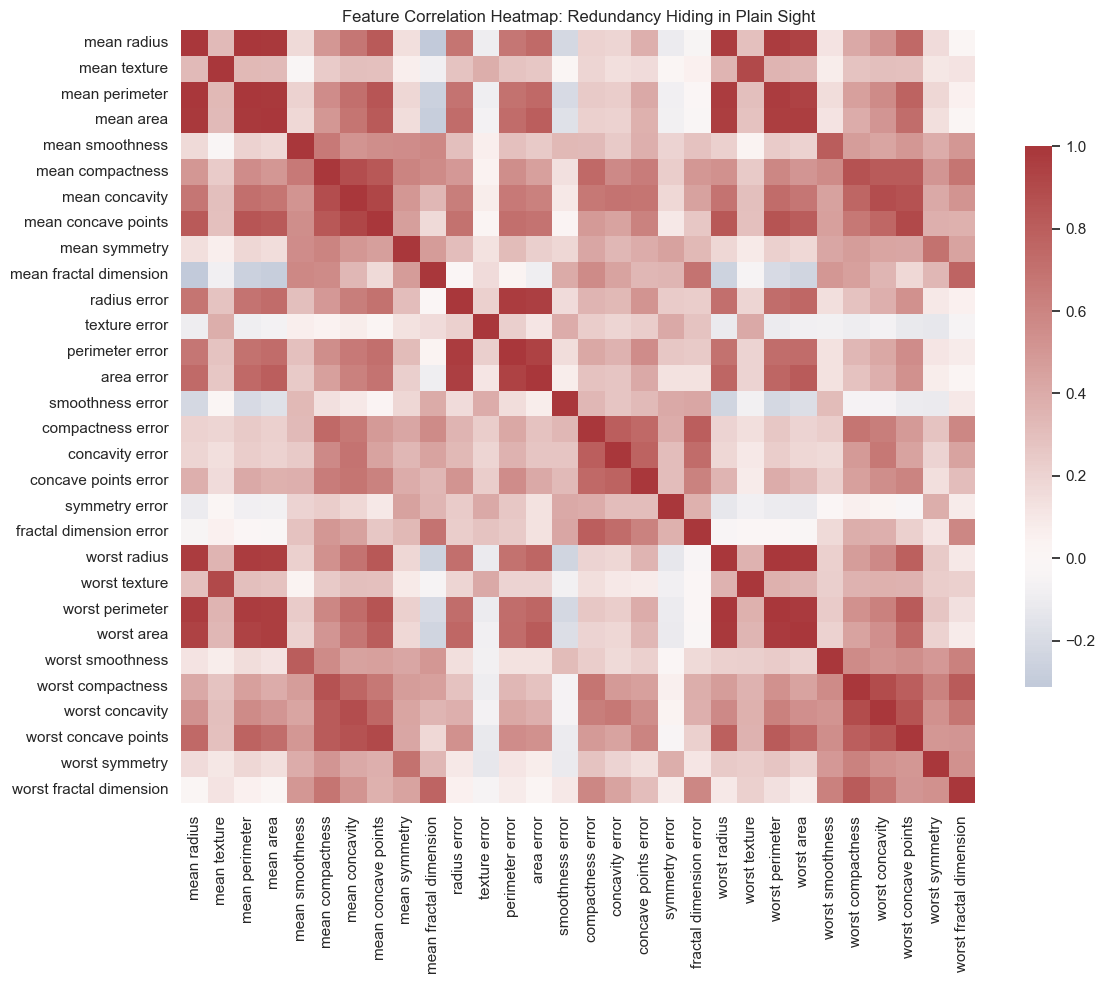

In [4]:
X, y = split_features_target(df)
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), cmap="vlag", center=0, cbar_kws={"shrink": 0.7})
plt.title("Feature Correlation Heatmap: Redundancy Hiding in Plain Sight")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

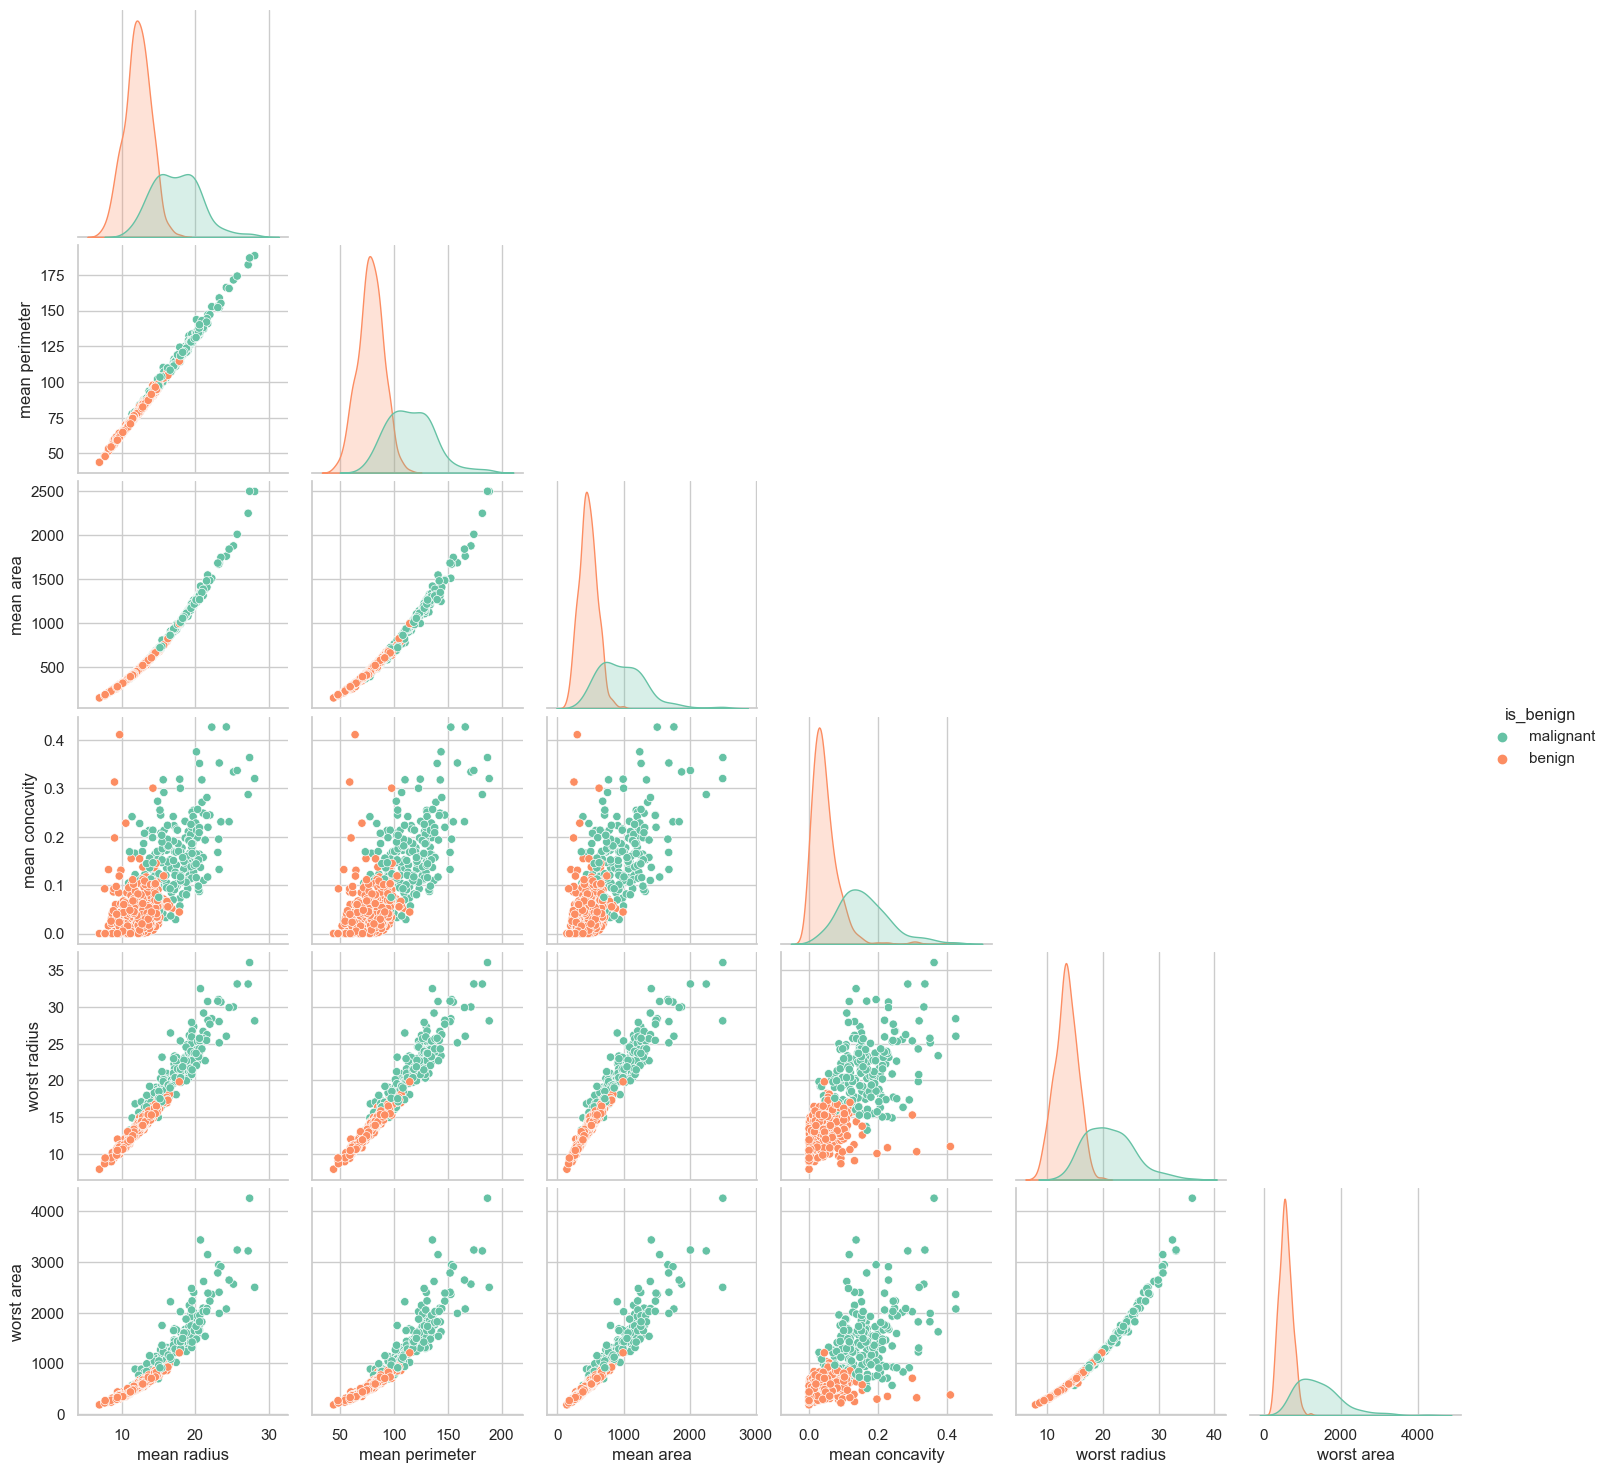

In [5]:
selected_features = ["mean radius", "mean perimeter", "mean area", "mean concavity", "worst radius", "worst area"]
plot_df = df[selected_features + [TARGET_COLUMN]].copy()
plot_df[TARGET_COLUMN] = plot_df[TARGET_COLUMN].map({0: "malignant", 1: "benign"})
sns.pairplot(plot_df, hue=TARGET_COLUMN, corner=True)
plt.savefig(IMAGES_DIR / "pairplot_correlated_features.png", dpi=160, bbox_inches="tight")
plt.show()

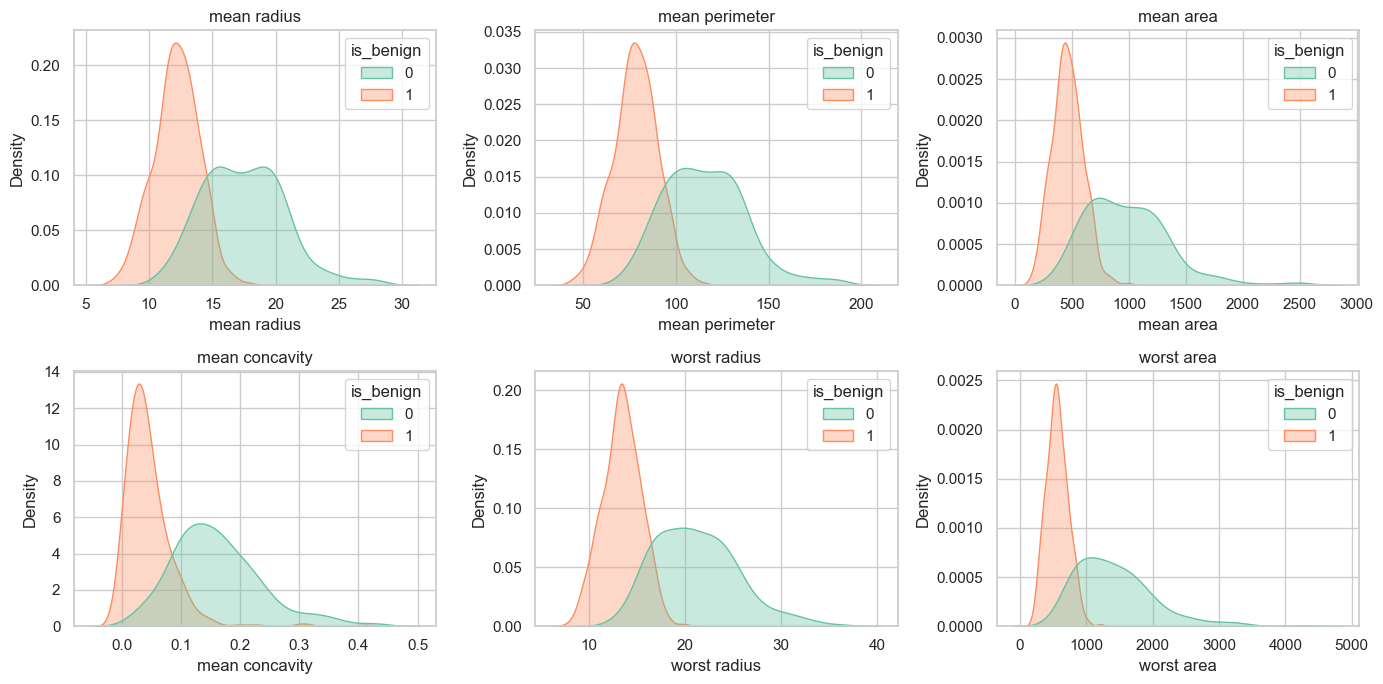

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), selected_features):
    sns.kdeplot(data=df, x=col, hue=TARGET_COLUMN, fill=True, common_norm=False, alpha=0.35, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Why Scaling Matters for PCA

PCA is variance-sensitive.

If one feature has a huge numeric scale, PCA may treat it as more important simply because its values are larger. Scaling makes PCA listen to patterns instead of measurement units.

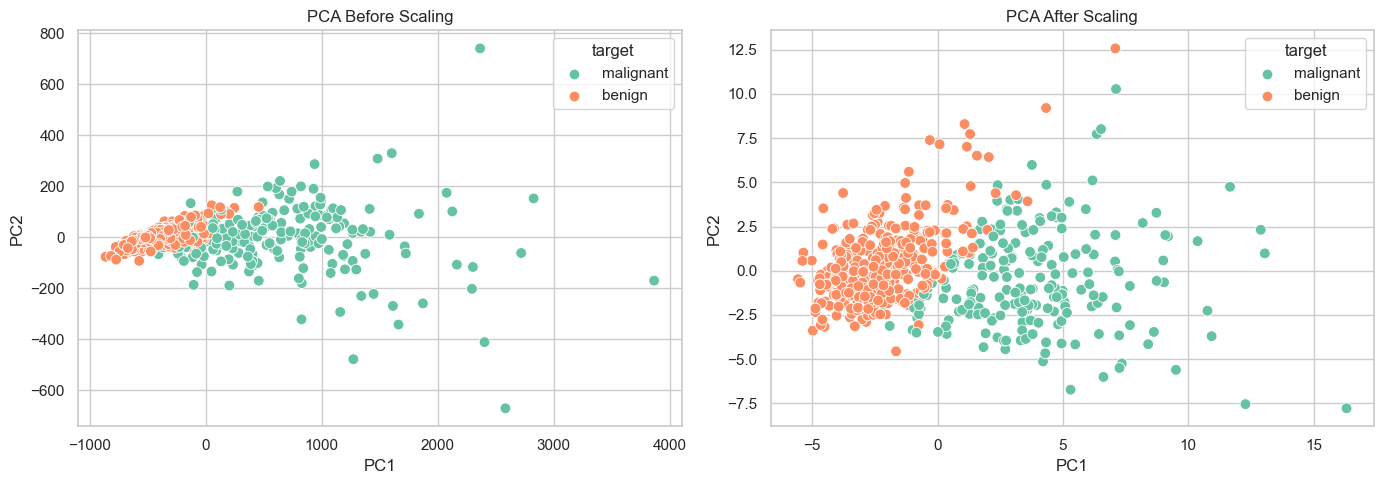

In [7]:
pca_raw, raw_pca_df = fit_pca(X, n_components=2)
X_scaled, scaler = scale_features(X)
pca_scaled_2, scaled_pca_df = fit_pca(X_scaled, n_components=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pca_df, title in zip(axes, [raw_pca_df, scaled_pca_df], ["PCA Before Scaling", "PCA After Scaling"]):
    temp = pca_df.copy()
    temp["target"] = y.map({0: "malignant", 1: "benign"})
    sns.scatterplot(data=temp, x="PC1", y="PC2", hue="target", s=60, edgecolor="white", ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "scaling_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Understanding Variance Intuitively

Variance is movement.

If data spreads strongly in one direction, that direction carries information about how examples differ. PCA keeps the directions with the most meaningful spread.

Low-variance directions may still contain information, but they often contain smaller details or noise.

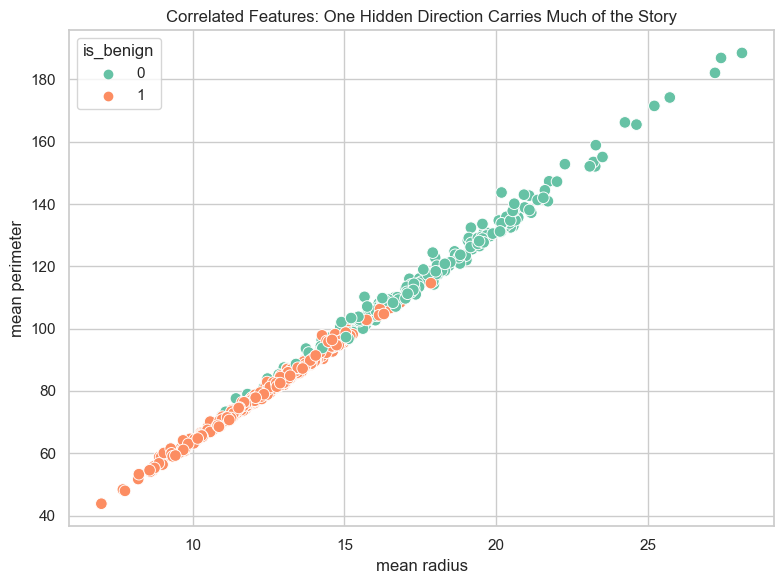

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="mean radius", y="mean perimeter", hue=TARGET_COLUMN, s=70, edgecolor="white")
plt.title("Correlated Features: One Hidden Direction Carries Much of the Story")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "variance_direction_intuition.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Applying PCA

We fit PCA on scaled features. The transformed columns are principal components: new compressed features built from combinations of the original measurements.

In [9]:
pca_full, pca_full_df = fit_pca(X_scaled, n_components=None)
variance_df = explained_variance_table(pca_full)
pca_2, pca_2_df = fit_pca(X_scaled, n_components=2)
pca_3, pca_3_df = fit_pca(X_scaled, n_components=3)
variance_df.head(10).round(4)

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.4427,0.4427
1,PC2,0.1897,0.6324
2,PC3,0.0939,0.7264
3,PC4,0.0660,0.7924
4,PC5,0.0550,0.8473
5,PC6,0.0402,0.8876
6,PC7,0.0225,0.9101
7,PC8,0.0159,0.9260
8,PC9,0.0139,0.9399
9,PC10,0.0117,0.9516


## 12. Explained Variance Ratio

Explained variance tells us how much information each component captures.

Cumulative explained variance tells us how much information we keep as we add components.

This is the compression tradeoff: fewer components mean simpler data, but more information loss.

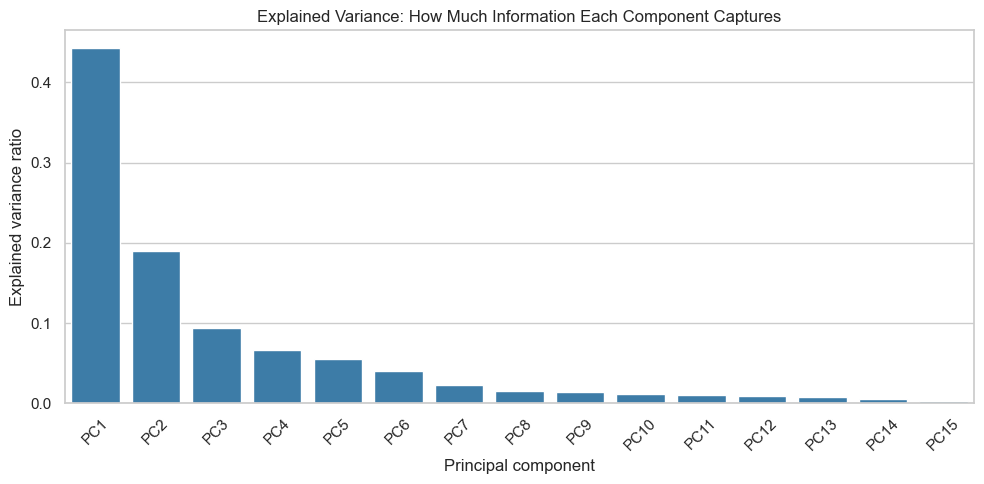

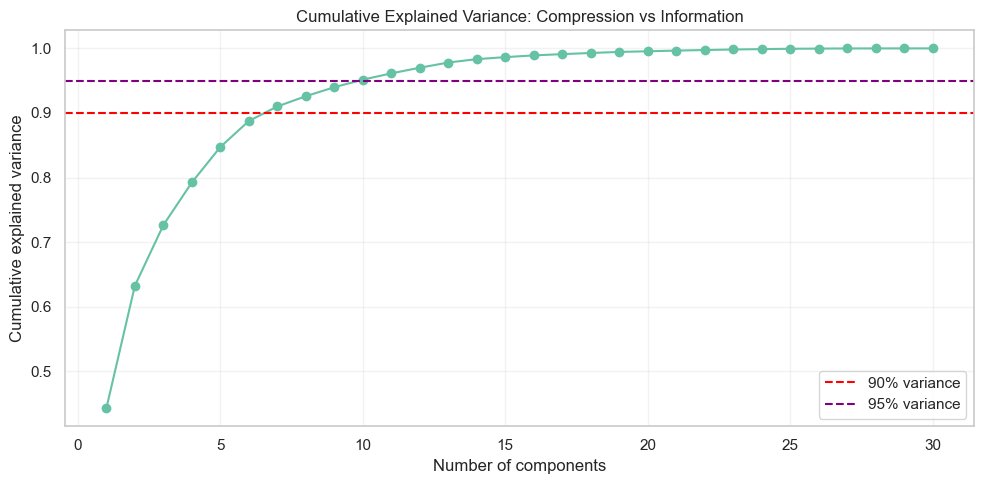

Components for 90% variance: 7
Components for 95% variance: 10


In [10]:
plot_explained_variance(variance_df, IMAGES_DIR / "explained_variance.png")
plt.show()
plot_cumulative_variance(variance_df, IMAGES_DIR / "cumulative_variance.png")
plt.show()
components_90 = int((variance_df["cumulative_variance"] >= 0.90).idxmax() + 1)
components_95 = int((variance_df["cumulative_variance"] >= 0.95).idxmax() + 1)
print("Components for 90% variance:", components_90)
print("Components for 95% variance:", components_95)

## 13. Visualizing Data After PCA

Now 30 original features collapse into two principal components.

The model did not use the diagnosis label to create this view. Yet the structure becomes visible because PCA found strong hidden directions in the measurements.

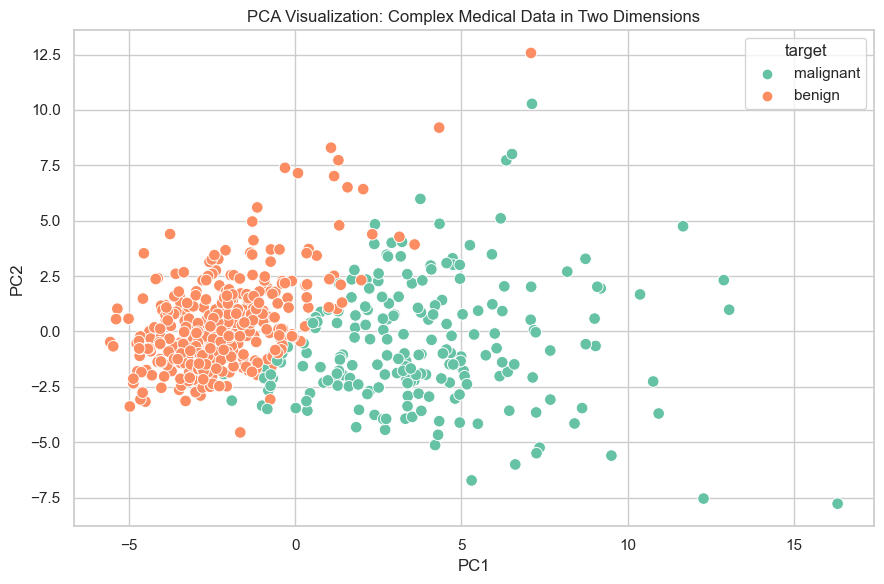

In [11]:
plot_pca_scatter(pca_2_df, y, IMAGES_DIR / "pca_visualization.png")
plt.show()

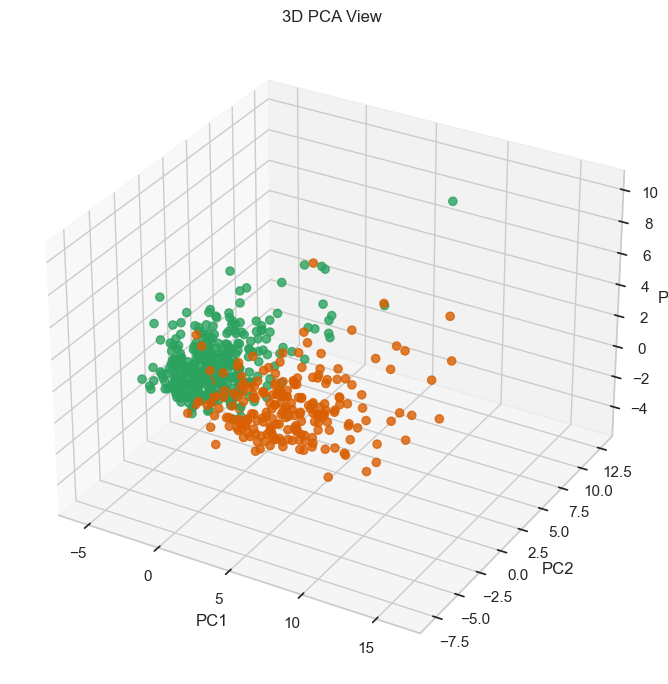

In [12]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
colors = y.map({0: "#d95f02", 1: "#2ca25f"})
ax.scatter(pca_3_df["PC1"], pca_3_df["PC2"], pca_3_df["PC3"], c=colors, s=35, alpha=0.8)
ax.set_title("3D PCA View")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "pca_3d_visualization.png", dpi=160, bbox_inches="tight")
plt.show()

## 14. PCA for Noise Reduction

PCA can reduce noise by keeping the strongest components and dropping weaker directions.

This is not the same as saying low-variance directions are useless. It means we can choose a simpler representation when compression is worth a small amount of information loss.

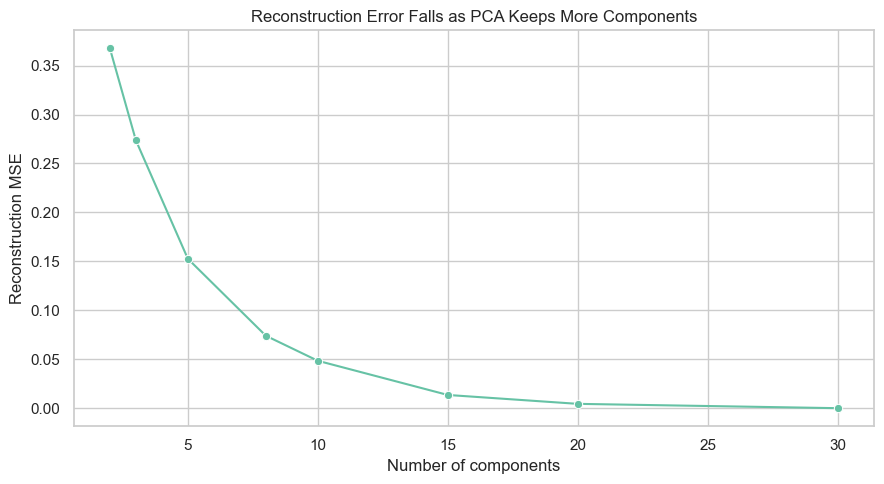

,n_components,reconstruction_mse,cumulative_variance
0,2,0.3676,0.6324
1,3,0.2736,0.7264
2,5,0.1527,0.8473
3,8,0.0740,0.9260
4,10,0.0484,0.9516
5,15,0.0135,0.9865
6,20,0.0044,0.9956
7,30,0.0000,1.0000


In [13]:
reconstruction_df = reconstruction_error_by_components(X_scaled, component_counts=[2, 3, 5, 8, 10, 15, 20, 30])
plt.figure(figsize=(9, 5))
sns.lineplot(data=reconstruction_df, x="n_components", y="reconstruction_mse", marker="o")
plt.title("Reconstruction Error Falls as PCA Keeps More Components")
plt.xlabel("Number of components")
plt.ylabel("Reconstruction MSE")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "reconstruction_error.png", dpi=160, bbox_inches="tight")
plt.show()
reconstruction_df.round(4)

## 15. PCA for Machine Learning

PCA can reduce computational cost and sometimes reduce overfitting by replacing many correlated features with fewer compressed components.

We compare Logistic Regression using all 30 original features against Logistic Regression using PCA components.

In [14]:
comparison_df = compare_model_with_without_pca(X, y, n_components=components_95)
comparison_df.round(4)

,model,features_used,accuracy,f1,roc_auc
0,Original features,30,0.986,0.9889,0.9977
1,PCA 10 components,10,0.979,0.9832,0.9973


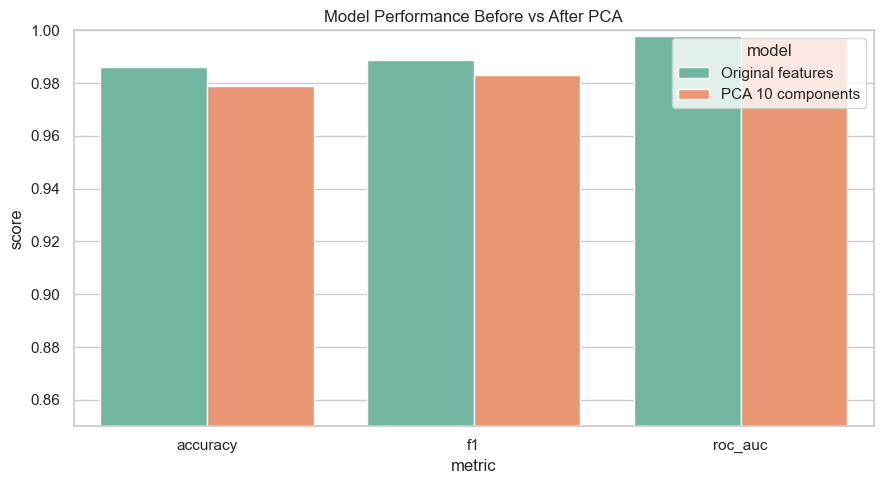

In [15]:
plt.figure(figsize=(9, 5))
plot_df = comparison_df.melt(id_vars=["model", "features_used"], value_vars=["accuracy", "f1", "roc_auc"], var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.title("Model Performance Before vs After PCA")
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## 16. Understanding Principal Components

Principal components are combinations of original features.

Loadings show how strongly each original feature contributes to a component. This is useful, but PCA components can be harder to interpret than original columns because each component mixes many features.

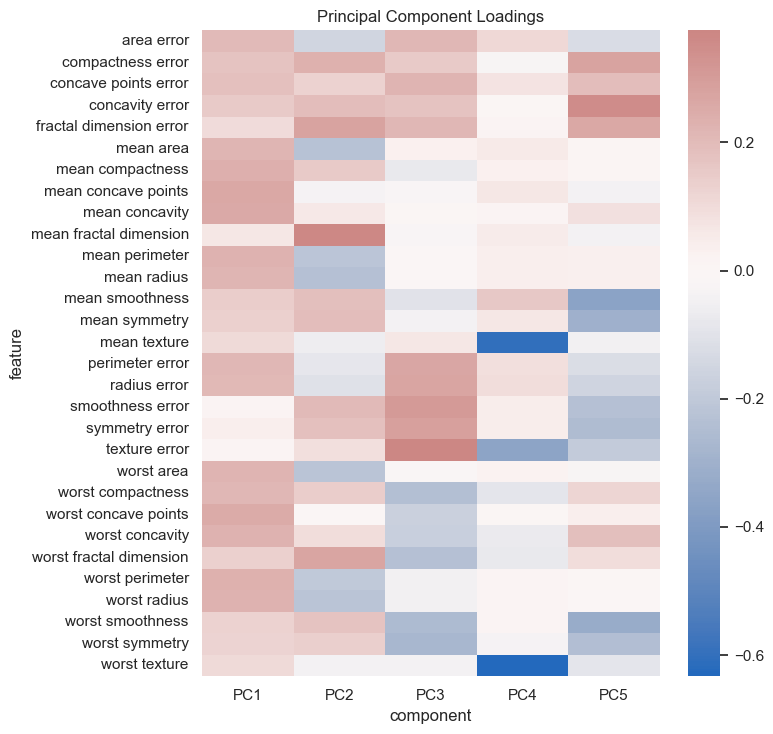

,component,feature,loading,abs_loading
7,PC1,mean concave points,0.260854,0.260854
6,PC1,mean concavity,0.258400,0.258400
27,PC1,worst concave points,0.250886,0.250886
5,PC1,mean compactness,0.239285,0.239285
22,PC1,worst perimeter,0.236640,0.236640
26,PC1,worst concavity,0.228768,0.228768
20,PC1,worst radius,0.227997,0.227997
2,PC1,mean perimeter,0.227537,0.227537
23,PC1,worst area,0.224871,0.224871
3,PC1,mean area,0.220995,0.220995


In [16]:
loadings_df = component_loadings(pca_full, X.columns, n_components=5)
plot_loadings_heatmap(loadings_df, IMAGES_DIR / "component_loadings.png")
plt.show()
top_loadings(loadings_df, "PC1", n=10)

## 17. Limitations of PCA

PCA is elegant, but not universal.

It is linear. It is sensitive to scaling. It can lose information. Its components are harder to interpret than original features. It may miss nonlinear structures that t-SNE, UMAP, or autoencoders can reveal.

## 18. Real-World Applications

PCA appears in image compression, recommendation systems, finance, genomics, computer vision, NLP embeddings, anomaly detection, and sensor analytics.

It is useful whenever data is high-dimensional, correlated, and too complex to inspect directly.

## 19. PCA vs t-SNE vs UMAP Mini Comparison

PCA is linear and preserves broad global structure.

t-SNE is nonlinear and focuses on local neighborhoods for visualization.

UMAP is nonlinear and often preserves both local and some global structure better than t-SNE.

PCA is usually the simplest, fastest, and most interpretable first step.

## 20. Final Takeaway

PCA does not make data smaller by ignoring complexity.

It makes data smaller by finding the directions where the important complexity lives.

That is why PCA feels almost magical: it reveals that high-dimensional data may be simpler than it first appears.

## 21. Interview Questions

For detailed interview preparation, see:

`pca/interview_questions.md`

The companion interview article explains these concepts in practical ML engineering language.